# MLP from scratch for MNIST classification 

## Introduction
In this notebook, we will code from scratch an MLP (mutli-layer perceptron) for the classification task on MNIST dataset. Everything in the algorithm -from forward propagation to backpropagation and optimization- were be written from scratch.
We will also experiment with different configurations and architectures to observe how various parameters affect the learning process. 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Importing and analyzing the dataset

In [3]:
# Importing the training and the test datasets
trainset = pd.read_csv("digit-recognizer/train.csv")
testset = pd.read_csv("digit-recognizer/test.csv")

In [4]:
print("trainset shape :",trainset.shape)
print("testset shape :",testset.shape)

trainset shape : (42000, 785)
testset shape : (28000, 784)


In [5]:
print(trainset.isnull().sum().sum())
print(testset.isnull().sum().sum())

# there are no null values in the dataset

0
0


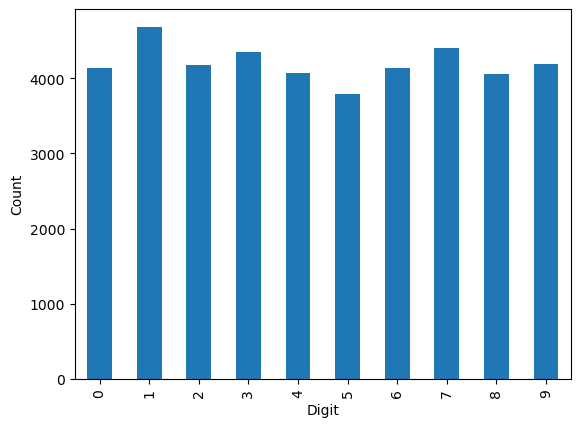

In [6]:
trainset.value_counts("label").sort_index().plot(kind="bar")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

# The dataset is balanced. Each class has around 3500 samples. 

In [7]:
#splitting the training dataset into the training and the validation datasets
validset = trainset.sample(frac=0.2, random_state=42)
trainset = trainset.drop(validset.index)

print(trainset.shape)
print(validset.shape)

(33600, 785)
(8400, 785)


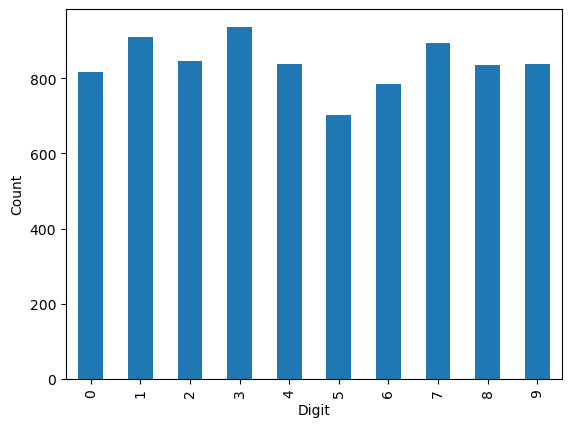

In [8]:
validset.value_counts("label").sort_index().plot(kind="bar")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

In [9]:
X = trainset.drop("label", axis=1).values #drop the label
y = trainset["label"].values #the true classes
print("X shape : ",X.shape)
print("y shape : ",y.shape)

X shape :  (33600, 784)
y shape :  (33600,)


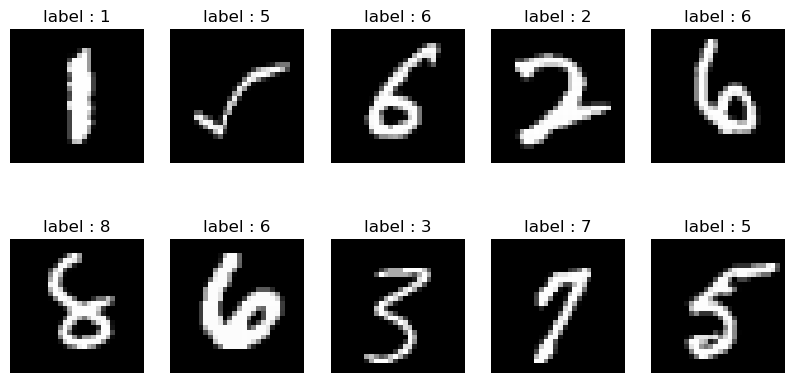

In [10]:
# Visualize random samples from the dataset

fig, axes = plt.subplots(2, 5, figsize=(10,5))

random_indices = np.random.choice(X.shape[0], size=10, replace=False)

for i, ax in zip(random_indices, axes.flat) : 
    ax.imshow(X[i].reshape(28,28), cmap="gray")
    ax.set_title(f"label : {y[i]}")
    ax.axis("off")

plt.show()

# In the ten random examples displayed above, all the digits correspond to their labels. 
# This indicates that the dataset is clean and there are no errors in the labels.
# All the examples are well centered. We can see clearly some difference between the the styes of hand-writting
# for the same digits. This provides a good variety (mathematically with a high variance) of examples for the model to learn from. 

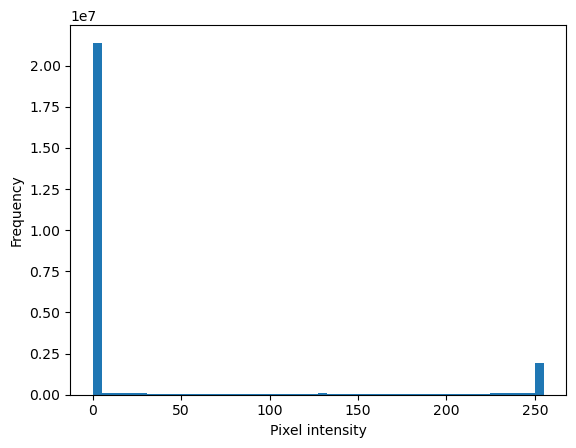

In [11]:
plt.hist(X.ravel(), bins=50)
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.show()

# The code displays the distribution of pixel intensities in the dataset. The pixel intensity values range from
# 0 to 255. The histogram shows a strong concentration of pixel values near zero, indicating that most pixels 
# correspond to the black background.


In [12]:
# Normalization of the pixel intensity values to the range [0,1]
X = X / 255.0

Why do we need normalization ?
There are several important reasons : 
- faster and more stable training : without normalization, the features with large scale will be much more influencial on the gradient then the other ones. This will create a imbalance between features and therefore the model will biased to consider that large features are more important then small ones which not generally true. Also gradient descent converges well with features on the same scale.
- prevents exploding activations : a large input could get larger and larger through layers. This could lead to numerical overflow, neuron saturation, vanishing gradients, and unstable training.

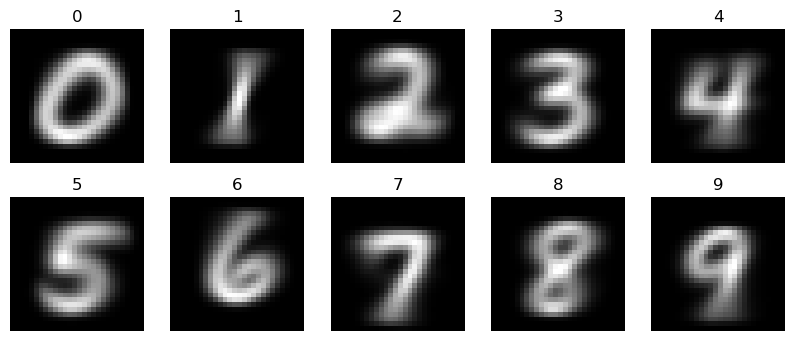

In [13]:
## mean image per class

fig, axes = plt.subplots(2,5, figsize = (10,4))

for digit in range(10):
    mean_img = X[y==digit].mean(axis=0).reshape(28,28)
    axes[digit//5, digit%5].imshow(mean_img, cmap = "gray")
    axes[digit//5, digit%5].set_title(str(digit))
    axes[digit//5, digit%5].axis("off")

## We see clearly that the mean image of each digit corresponds to its label with a little bit of blurr. This shows that the dateset is well classified and
## and with some variance.

Text(0.5, 1.0, 'Pixel')

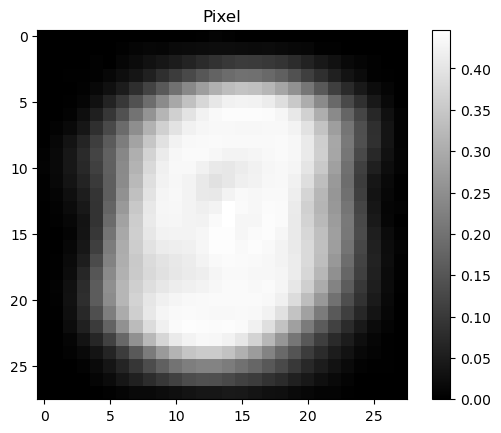

In [14]:
## Variance images
std_img = X.std(axis=0).reshape(28,28)
plt.imshow(std_img, cmap = "grey")
plt.colorbar()
plt.title("Pixel")

# As we see in the figure, the variance is very high in the center of the image and very low on the boundaries. This outcome is expected given that most
# digits are generally centered so the pixels on the limits are dark and so have the same value 0, and therefore have a low variance. The exact opposite 
# happens in the center.

## Building the model 
### Initializing the parameters
The literature suggests multiple methods of initialization. We choose among them the He initialization where the weights are drawn as : 
$$ W \sim \mathcal{N}(0, \sqrt{2/n_{\text{in}}}) $$

We decided to use He initialization because it is the one that suits the most Relu, the activation function that we will use in our MLP. 

How He initialization is adapted to the Relu function ?
Relu sets half of the inputs on average to zero.
So roughly 50% of activations vanish.
If we used a naive initialization, ,the variance of activations would shrink layer after layer, causing :
vanishing signals
slow training
He initialization compensates for this by doubling the variance.


In [15]:
def he_initial(n_in, n_out):
    W = np.random.randn(n_in, n_out) * np.sqrt(2. / n_in)
    b = np.zeros((1, n_out)) #bias is initialized to zero
    return W, b


### Fully connected layer
The fully connected layer is a layer where each neuron is connected to each input. This design allows the network to learn complex relationships between features. We implement it as a class so it can be easily reused and combined with other layers in our MLP.

In [16]:
class FCLayer :
    """fully connected layer"""

    def __init__(self, n_in, n_out):
        self.n_in = n_in
        self.n_out = n_out
        self.W, self.b = he_initial(n_in,n_out)


    def forward(self, X):
        return np.dot(X,self.W) + self.b

### Activation functions


The activation functions are very important to neural networks. Without them, stacking multiple linear layers is mathematically equivalent to a single linear layer, making the network incapable of representing non-linear functions.
are different activation functions used in different contexts. In our neural network, we used Relu for the first and second layer and softmax for the last one.

Why softmax ?
Softmax is used generally for classification tasks. It converts logits to probabilities that sum to 1, enabling probabilistic interpretation for mutually exclusive classes.

Why Relu ?
Relu is very popular in deep learning for differents reasons. The computation of the function and its derivative are light so it does not slow down the neither the forwardpropagation or backpropagation. Also, it does not cause the gradient to vanish. But Relu has its limitations : 
- Dying ReLU problem: Neurons can become permanently inactive (output 0 for all inputs)

- Not zero-centered: Can cause optimization issues. This quite tricky to explain. Actually, in the particular case where all the inputs x have the same sign, the gradient will also have the same sign, so the update of the different weights due to the gradient descent moves only in one direction(negative or positive). This leads to a slow convergence towards the minima because the algorithm zigzags instead of going directly.


In [17]:
def Relu(x) :
    return np.maximum(0,x)

def relu_derivative(x):
    return (x > 0).astype(float)

In [18]:
def softmax(x): 
    exp_scores = np.exp(x - np.max(x, axis=1, keepdims=True))  # for numerical stability
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)


### Loss
We use the cross-entropy loss because this is a classification problem. To properly understand this loss function, it is first important to understand the role of the softmax function.

The purpose of the softmax function is to convert the raw scores produced by the network into a probability distribution over the different classes. From an information theory perspective, cross-entropy measures the discrepancy between two probability distributions: the true distribution, represented by the one-hot encoded labels, and the predicted distribution, given by the output of the softmax function. The objective is therefore to minimize the difference between these two distributions, which corresponds to minimizing the loss.

This loss can also be interpreted from a probabilistic perspective. Minimizing the cross-entropy loss is equivalent to maximizing the log-likelihood of the correct class (or equivalently minimizing the negative log-likelihood), which leads to the optimal model parameters.

In [19]:
def compute_loss(outputs, y, reg_lambda, W, K):
    one_hot_labels = np.zeros((y.shape[0], K))
    one_hot_labels[np.arange(len(y)),y] = 1
    data_loss  = -np.mean(np.sum(one_hot_labels * np.log(outputs), axis=1))
    reg_loss = 0
    for w in W : 
        reg_loss += 0.5 * reg_lambda * np.sum(w*w)
    return data_loss + reg_loss


### Backpropagation
Backpropagation is an algorithm for efficiently computing gradients in neural networks. In deep networks, the loss as a function of the weights is a highly complex composition of operations, making direct analytical derivation of the gradients impractical. Backpropagation leverages the chain rule to compute gradients layer by layer, starting from the output and moving backward toward the input. By storing intermediate values from the forward pass and reusing them during the backward pass, the algorithm avoids redundant computations and keeps the per-layer gradient calculations relatively simple. 

In [20]:
def backpropagation(X, Z1, A1, Z2, A2, Z3, A3, y, W2, W3):

    m = X.shape[0] #number of examples
    #output layer gradients
    one_hot_encoding = np.zeros((m,A3.shape[1]))
    one_hot_encoding[np.arange(m), y] = 1
    dZ3 = A3 - one_hot_encoding
    dW3 = np.dot(A2.T, dZ3)/m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m

    #second hidden layer gradients
    dA2 = np.dot(dZ3, W3.T) 
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = np.dot(A1.T, dZ2)/m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # first hidden layer gradients
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return  dW1, db1, dW2, db2, dW3, db3

### Optimization

In [21]:
def optimizer_GD(learning_rate, W, b,dW, db): 
    "optimizes the loss function using the gradient descent algorithm"
    for i in range(len(W)):
        W[i] -= learning_rate * dW[i]
        b[i] -= learning_rate * db[i]
    


In [ ]:
n_in, n_hidden_1, n_hidden_2, n_out = X.shape[1], 200,20, 10
reg_lambda = 0.01
learning_rate = 0.01
K = 10

layer1 = FCLayer(n_in, n_hidden_1)
layer2 = FCLayer(n_hidden_1, n_hidden_2)
layer3 = FCLayer(n_hidden_2, n_out)

epochs = 2000

for epoch in range(epochs): 
    Z_1 = layer1.forward(X)
    A_1 = Relu(Z_1)

    Z_2 = layer2.forward(A_1)
    A_2 = Relu(Z_2)

    Z_3 = layer3.forward(A_2)
    A_3 = softmax(Z_3)


    loss = compute_loss(A_3, y, reg_lambda, W=[layer1.W, layer2.W, layer3.W],K=K)
    ## backpropagation code will go here
    dW1, db1, dW2, db2, dW3, db3 = backpropagation(X, Z_1, A_1, Z_2, A_2, Z_3, A_3,y, layer2.W, layer3.W)    

    ## update weights and biases using the optimizer
    optimizer_GD(learning_rate, W=[layer1.W, layer2.W, layer3.W], b=[layer1.b, layer2.b, layer3.b], dW=[dW1, dW2, dW3], db=[db1, db2, db3])

    if epoch % 10 == 0 : 
        print(f"epoch n : {epoch} / loss : {loss}")



epoch n : 0 / loss : 4.806966965280191
epoch n : 10 / loss : 4.5687350544945655
epoch n : 20 / loss : 4.503909927481561
epoch n : 30 / loss : 4.459120308810968
epoch n : 40 / loss : 4.418665188262468
epoch n : 50 / loss : 4.3785707138438905
epoch n : 60 / loss : 4.337592885306243
epoch n : 70 / loss : 4.295387114863917
epoch n : 80 / loss : 4.251976118776352
epoch n : 90 / loss : 4.207524513138925
epoch n : 100 / loss : 4.162259389104294
epoch n : 110 / loss : 4.116278980888668
epoch n : 120 / loss : 4.0695169874355
epoch n : 130 / loss : 4.022302136035433
epoch n : 140 / loss : 3.974813139273266
epoch n : 150 / loss : 3.9276121020351153
epoch n : 160 / loss : 3.880935327236468
epoch n : 170 / loss : 3.834954141741592
epoch n : 180 / loss : 3.78965086429508
epoch n : 190 / loss : 3.7451259449775183
epoch n : 200 / loss : 3.7015116549069518
epoch n : 210 / loss : 3.6589210462239237
epoch n : 220 / loss : 3.6174164831210875
epoch n : 230 / loss : 3.577051710726919
epoch n : 240 / loss : 

In [23]:
## computing the accuracy

predicted_class = np.argmax(A_3, axis=1)
print(f"accuracy on the training dataset : {np.mean(predicted_class==y)*100:.2f}%")

accuracy on the training dataset : 91.24%


## Validation

In [24]:
X_valid = validset.drop("label", axis=1)
y_valid = validset["label"]

In [25]:
Z_1 = layer1.forward(X_valid)
A_1 = Relu(Z_1)
Z_2 = layer2.forward(A_1)
A_2 = Relu(Z_2)

Z_3 = layer3.forward(A_2)
A_3 = softmax(Z_3)


In [28]:
print(A_3.shape)
predicted_class = np.argmax(A_3, axis=1)
print(f"accuracy on the validation set : {np.mean(predicted_class==y_valid)*100:.2f}%")

## The accuracy of the model on the validation set is : 0.90. It is a pretty good accuracy but it could get better with some hyperparameter tunning.

(8400, 10)
accuracy on the validation set : 90.55%


## Hyperparameter tunning
### Introduction

With the architecture and the parameters we have used, we obtained an accuracy of 90% on the validation set. It is a pretty decent result but it is below
what is usually expected. In this situation comes the role of hyperparameter tunning.

What is hyperparameter tuning ?

Hyperparameter tuning consists of trying different values for a certain parameter and select the one that makes the model more performant. We can group 
hyperparameters in three big families : 

**Architecture :**
- number of hidden layers
- dimension of each layer

**Optimization :** 
- optimizer 
- learning rate
- batch size
- number of epochs

**Regularization :**
- regularization technique (Ridge, Lasso, Dropout ...)
- regularization coefficient 

How do we do hyperparameter tuning ?

we may thing that the best combination of hyperparameters would be the combination of the most optimal hyperparameters selected individually. Adopting this logic, we would go through the chosen values for each hyperparameter, select the optimal one and keep it. We move then to the next hyperparameter while using for the hyperparameterd already tested the optimal values found. 

The problem is that the statement said before is wrong. The most optimal combination is not forcefully the combination of the most optimal values of hyperparameters. Therefore, we need to test all possible combinations for all values for hyperparameters. This search method is called grid search. It is a systematic approach but very expensive. 

To avoid the cost problem, there is a second search method called random search. It consists of randomly sampling combinations. It is often better then grid search in practice. 

The third method is Bayesian optimization. Libraries like Optuna use previous results to suggest better trials. This is usually the best method when tuning many hyperparameters.

### Tuning strategy
It would be costy to just do brute-force tuning. We need a clear strategy based on the performance of the model.

We observe that training and validations accuracies are very close. Therefore the model is not overfitting. However, the training accuracy is low which means the model is not memorizing the model very well. The first suspects of this anomaly is : hidden layers and learning rate. We will prioritize those two hyperparameters in the beginning of our strategy. 

In [ ]:
best_score = 0
best_parameters = None

for lr in [0.01, 0.001]:
    for n_hidden_1 in []:
        for n_hidden_2 in []:
            # Train the model with the current set of parameters
            